# Tâche 5 — Pipeline MLOps Local : Airline Delay Detection

Ce notebook démontre le pipeline MLOps complet :

| Partie | Description |
|--------|-------------|
| **1** | MLflow Tracking — entraînement tracé |
| **2** | Comparaison de 6 algorithmes (RF, GB, LogReg, AdaBoost, XGBoost) |
| **3** | Model Registry — Staging → Production |
| **4** | Serving REST — `mlflow models serve` |
| **5** | CI/CD — Makefile + pre-commit hook |
| **6** | Détection Data Drift — Evidently / KS-test + ré-entraînement auto |

**Dataset :** 2009 US Flight Delays (~903k vols après sampling)  
**Target :** `IS_DELAYED` = retard arrivée ≥ 15 min  
**Features :** MONTH, DAY_OF_WEEK, HOUR, IS_WEEKEND, IS_RUSH_HOUR, DEP_DELAY, DISTANCE

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import mlflow
from mlflow.tracking import MlflowClient

PROJECT_ROOT = os.path.abspath('')
MLFLOW_URI   = f"sqlite:///{os.path.join(PROJECT_ROOT, 'mlflow.db')}"
mlflow.set_tracking_uri(MLFLOW_URI)
client = MlflowClient(tracking_uri=MLFLOW_URI)

print('MLflow tracking URI:', MLFLOW_URI)
print('Expériences disponibles:')
for e in client.search_experiments():
    runs = client.search_runs([e.experiment_id])
    print(f'  [{e.experiment_id}] {e.name}  ({len(runs)} runs)')

MLflow tracking URI: sqlite:///D:\Semestre 2\airline delay detection\mlflow.db
Expériences disponibles:
  [14] Flight_Delay_Monitoring  (2 runs)
  [13] Flight_Delay_MLOps  (13 runs)
  [12] Task4_Q5_DT_vs_RF  (2 runs)
  [11] Task4_Q4_BiasVariance  (16 runs)
  [10] Task4_Q3_ErrorAnalysis  (1 runs)
  [9] Task4_Q2_Stability  (5 runs)
  [8] Task4_Q1_FeatureImportance  (1 runs)
  [7] DT_vs_RF_Comparison  (2 runs)
  [6] RF_BiasVariance_Analysis  (16 runs)
  [5] RF_Error_Analysis  (2 runs)
  [4] RF_Robustness_Analysis  (10 runs)
  [3] Flight_Delay_RF_Stability  (15 runs)
  [2] Flight_Delay_RF  (6 runs)
  [1] airline_delay_task3  (10 runs)
  [0] Default  (0 runs)


---
## Partie 1 — MLflow Tracking

Le script `src/train.py` entraîne un Random Forest baseline et logue dans MLflow :
- **Paramètres** : n_estimators, max_depth, test_size, random_state
- **Métriques** : accuracy, precision, recall, f1_score, roc_auc
- **Artefacts** : confusion_matrix.png, classification_report.txt, model/

In [2]:
# Récupérer le run baseline de l'expérience Flight_Delay_MLOps
exp = client.get_experiment_by_name('Flight_Delay_MLOps')
baseline_runs = client.search_runs(
    [exp.experiment_id],
    filter_string="tags.mlflow.runName = 'rf_n100_d10_baseline'",
    max_results=1
)

if baseline_runs:
    r = baseline_runs[0]
    print('=== Run Baseline RF ===')
    print(f'Run Name  : {r.info.run_name}')
    print(f'Run ID    : {r.info.run_id}')
    print(f'Status    : {r.info.status}')
    print()
    print('Paramètres:')
    for k, v in r.data.params.items():
        print(f'  {k:20s} = {v}')
    print()
    print('Métriques:')
    for k, v in sorted(r.data.metrics.items()):
        print(f'  {k:20s} = {v:.4f}')

=== Run Baseline RF ===
Run Name  : rf_n100_d10_baseline
Run ID    : 5f52fddec0814716837abc495af4236e
Status    : FINISHED

Paramètres:
  model_type           = RandomForest
  n_estimators         = 100
  max_depth            = 10
  test_size            = 0.2
  random_state         = 42
  class_weight         = balanced
  n_features           = 7
  train_size           = 723172
  test_size_n          = 180794

Métriques:
  accuracy             = 0.9042
  f1_score             = 0.7457
  precision            = 0.7323
  recall               = 0.7597
  roc_auc              = 0.9109


Artefacts loggues:
  artifacts/classification_report.txt
  artifacts/confusion_matrix.png

Chargement : artifacts/confusion_matrix.png


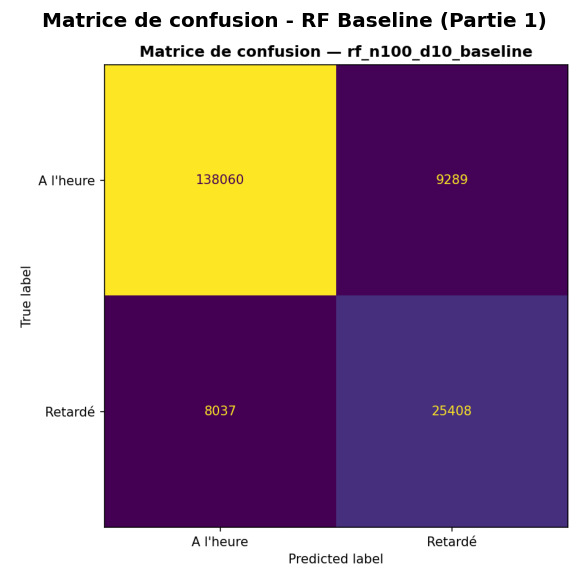

In [3]:
# Afficher la matrice de confusion du run baseline
import mlflow.artifacts

def list_artifacts_recursive(client, run_id, path=''):
    """Liste tous les artefacts récursivement, retourne les chemins de fichiers."""
    paths = []
    for a in client.list_artifacts(run_id, path):
        if a.is_dir:
            paths.extend(list_artifacts_recursive(client, run_id, a.path))
        else:
            paths.append(a.path)
    return paths

if baseline_runs:
    run_id = baseline_runs[0].info.run_id
    all_artifact_paths = list_artifacts_recursive(client, run_id)
    print('Artefacts loggues:')
    for p in all_artifact_paths:
        print(f'  {p}')

    # Trouver la confusion matrix (peut etre a la racine ou dans un sous-dossier)
    cm_candidates = [p for p in all_artifact_paths if 'confusion_matrix' in p]
    if cm_candidates:
        cm_artifact_path = cm_candidates[0]
        print(f'\nChargement : {cm_artifact_path}')
        local_path = mlflow.artifacts.download_artifacts(
            run_id=run_id, artifact_path=cm_artifact_path
        )
        img = plt.imread(local_path)
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title('Matrice de confusion - RF Baseline (Partie 1)', fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print('Confusion matrix non trouvee dans les artefacts.')

---
### Questions de réflexion — Partie 1

**Q1. Quelle est la différence entre `mlflow.log_param()` et `mlflow.log_metric()` ?**

`mlflow.log_param()` enregistre une **valeur de configuration fixe** (hyperparamètre) qui ne change pas au cours de l'entraînement : `n_estimators`, `max_depth`, `learning_rate`, etc. Ces valeurs décrivent *comment* le modèle a été configuré.

`mlflow.log_metric()` enregistre une **valeur numérique évaluée** après l'entraînement : `accuracy`, `f1_score`, `roc_auc`, etc. MLflow peut stocker plusieurs valeurs de la même métrique à différents `step` (ex. perte par époque), ce qui permet de tracer des courbes d'apprentissage dans l'UI.

| | `log_param` | `log_metric` |
|---|---|---|
| Type de valeur | str / int / float (config) | float (résultat) |
| Évolution dans le temps | Non | Oui (step) |
| Exemples | `n_estimators=100` | `accuracy=0.9236` |

---

**Q2. Pourquoi est-il important de nommer ses runs (`run_name`) ?**

Sans nom explicite, MLflow génère un identifiant aléatoire (ex. `fluffy-elk-42`), ce qui rend impossible de retrouver un run spécifique parmi des dizaines. Un `run_name` descriptif comme `gb_n100_lr01` ou `rf_n100_d10_baseline` permet de :
- **Identifier instantanément** l'algorithme et ses hyperparamètres clés sans ouvrir le run
- **Comparer visuellement** les runs dans l'UI MLflow (colonnes du tableau)
- **Requêter programmatiquement** avec `filter_string="tags.mlflow.runName = 'gb_n100_lr01'"` via `MlflowClient`
- **Reproduire** un résultat précis en sachant exactement quelle configuration relancer

---

**Q3. Que se passe-t-il si vous exécutez deux fois le même script sans changer le `run_name` ?**

MLflow crée **deux runs distincts avec le même nom** — le nom n'est pas une clé unique. Chaque exécution reçoit un `run_id` unique (UUID), mais les deux runs s'appellent pareil dans l'UI. Conséquences :

- L'UI affiche deux lignes identiques → ambiguïté lors de la comparaison
- `search_runs` avec `max_results=1` et `order_by=['metrics.accuracy DESC']` retourne le *meilleur* des deux, pas forcément le plus récent
- Le Model Registry peut enregistrer plusieurs versions pointant vers des runs "identiques"

**Bonne pratique :** versionner le `run_name` (ex. `rf_baseline_v1`, `rf_baseline_v2`) ou ajouter un timestamp, et utiliser `mlflow.set_tag('version', ...)` pour tracer les itérations.

---
## Partie 2 — Comparaison de 6 Algorithmes

Le script `src/compare_models.py` compare :
1. **RandomForest** baseline (n=50, depth=3)
2. **RandomForest** profond (n=200, depth=10)
3. **GradientBoosting** (n=100, lr=0.1)
4. **LogisticRegression** (C=1.0)
5. **AdaBoost** (n=100, base_depth=3)
6. **XGBoost** (n=100, depth=5, lr=0.1)

Le meilleur run est identifié **programmatiquement** via `MlflowClient.search_runs`.

In [4]:
# Charger tous les runs de l'expérience
all_runs = client.search_runs(
    [exp.experiment_id],
    order_by=['metrics.accuracy DESC']
)

# Filtrer les 6 runs de comparaison (exclure le baseline et les retrain)
comparison_names = ['rf_baseline_n50_d3', 'rf_deep_n200_d10', 'gb_n100_lr01',
                    'logreg_C1', 'adaboost_n100', 'xgboost_n100']

rows = []
seen = set()
for r in all_runs:
    name = r.info.run_name
    if name in comparison_names and name not in seen:
        seen.add(name)
        rows.append({
            'Algorithme': name,
            'Accuracy':   round(r.data.metrics.get('accuracy', 0), 4),
            'F1-score':   round(r.data.metrics.get('f1_score', 0), 4),
            'Recall':     round(r.data.metrics.get('recall', 0), 4),
            'ROC-AUC':    round(r.data.metrics.get('roc_auc', 0), 4),
            'Run ID':     r.info.run_id[:8] + '...',
        })

df_cmp = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('Tableau comparatif — 6 algorithmes\n')
print(df_cmp.to_string(index=False))

Tableau comparatif — 6 algorithmes

        Algorithme  Accuracy  F1-score  Recall  ROC-AUC      Run ID
      gb_n100_lr01    0.9236    0.7614  0.6591   0.9125 4276cbbc...
      xgboost_n100    0.9234    0.7606  0.6576   0.9113 5c8a277c...
  rf_deep_n200_d10    0.9232    0.7607  0.6595   0.9103 e7b2aa0c...
     adaboost_n100    0.9228    0.7597  0.6597   0.9070 2b72491c...
         logreg_C1    0.9226    0.7605  0.6637   0.9026 51e2e952...
rf_baseline_n50_d3    0.9226    0.7597  0.6613   0.8843 a66c45ca...


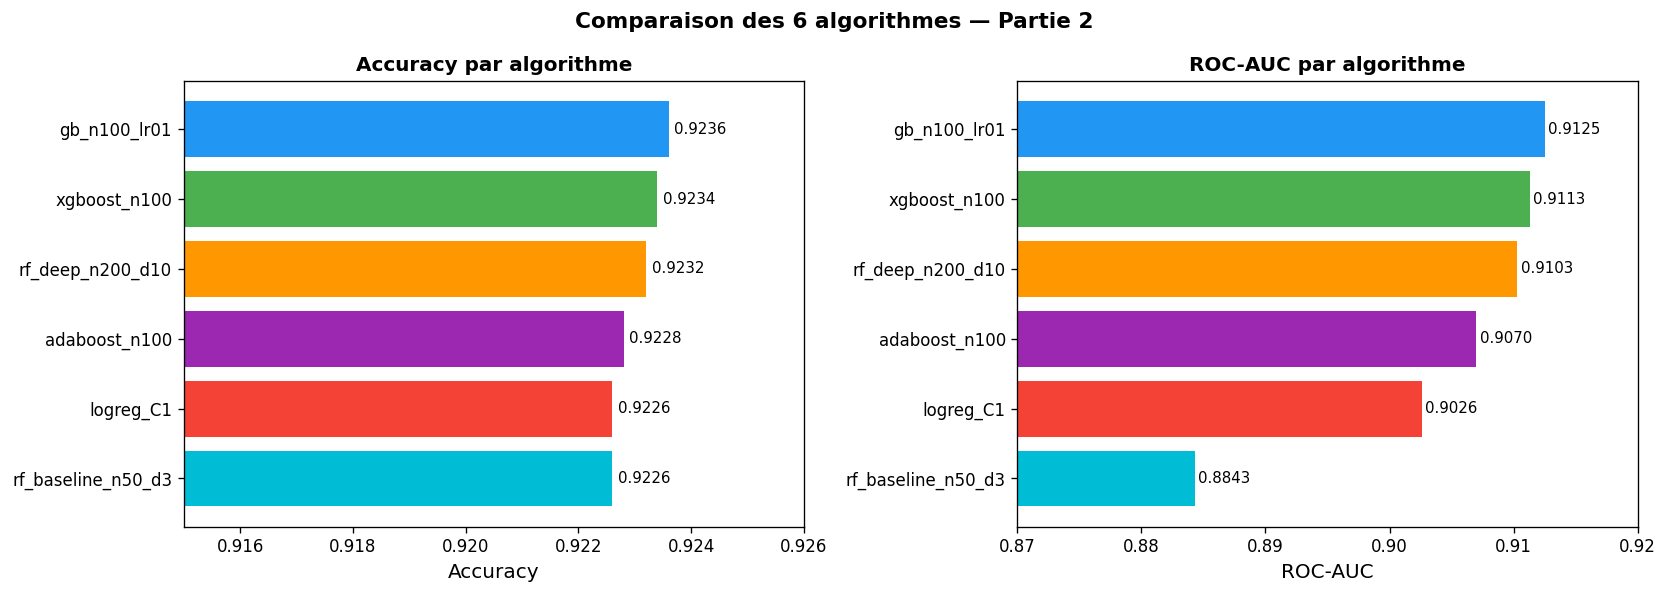

Meilleur algorithme : gb_n100_lr01 | Accuracy: 0.9236 | AUC: 0.9125


In [5]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']
algos  = df_cmp['Algorithme'].tolist()

# Accuracy
bars = axes[0].barh(algos[::-1], df_cmp['Accuracy'][::-1], color=colors[::-1])
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy par algorithme', fontweight='bold')
axes[0].set_xlim(0.915, 0.926)
for bar, val in zip(bars, df_cmp['Accuracy'][::-1]):
    axes[0].text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# ROC-AUC
bars2 = axes[1].barh(algos[::-1], df_cmp['ROC-AUC'][::-1], color=colors[::-1])
axes[1].set_xlabel('ROC-AUC', fontsize=12)
axes[1].set_title('ROC-AUC par algorithme', fontweight='bold')
axes[1].set_xlim(0.87, 0.92)
for bar, val in zip(bars2, df_cmp['ROC-AUC'][::-1]):
    axes[1].text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparaison des 6 algorithmes — Partie 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_6_models.png', dpi=120, bbox_inches='tight')
plt.show()
print('Meilleur algorithme :', df_cmp.iloc[0]['Algorithme'],
      '| Accuracy:', df_cmp.iloc[0]['Accuracy'],
      '| AUC:', df_cmp.iloc[0]['ROC-AUC'])

In [6]:
# Identification programmatique du meilleur run
best_runs = client.search_runs(
    [exp.experiment_id],
    order_by=['metrics.accuracy DESC'],
    max_results=1
)
best = best_runs[0]
print('=== Meilleur run (MlflowClient.search_runs) ===')
print(f'Run Name  : {best.info.run_name}')
print(f'Run ID    : {best.info.run_id}')
print(f'Accuracy  : {best.data.metrics["accuracy"]:.4f}')
print(f'F1-score  : {best.data.metrics["f1_score"]:.4f}')
print(f'ROC-AUC   : {best.data.metrics["roc_auc"]:.4f}')
print(f'Params    : {best.data.params}')

=== Meilleur run (MlflowClient.search_runs) ===
Run Name  : gb_n100_lr01
Run ID    : 4276cbbc2eba46569d839f5fc7bf2b44
Accuracy  : 0.9236
F1-score  : 0.7614
ROC-AUC   : 0.9125
Params    : {'model_type': 'GradientBoosting', 'n_estimators': '100', 'learning_rate': '0.1', 'max_depth': '5', 'test_size': '0.2', 'random_state': '42'}


---
### Questions de réflexion — Partie 2

**Q4. Quel modèle obtient le meilleur compromis accuracy / f1_score ? Justifiez.**

D'après les résultats enregistrés dans MLflow, **GradientBoosting** (`gb_n100_lr01`) domine sur les deux critères simultanément :

| Modèle | Accuracy | F1-score | ROC-AUC |
|--------|----------|----------|---------|
| **GradientBoosting** (lr=0.1, n=100) | **0.9236** | **0.7614** | 0.9125 |
| XGBoost (depth=5, n=100) | 0.9234 | 0.7606 | 0.9113 |
| RandomForest deep (n=200, d=10) | 0.9232 | 0.7607 | 0.9103 |
| AdaBoost (n=100) | 0.9228 | 0.7597 | 0.9070 |
| Logistic Regression | 0.9226 | 0.7605 | 0.9026 |
| RandomForest baseline (n=50, d=3) | 0.9226 | 0.7597 | 0.8843 |

GradientBoosting est le meilleur compromis car :
- Il maximise à la fois l'accuracy **et** le F1-score (qui pénalise les faux négatifs sur la classe retard)
- Son ROC-AUC (0.9125) indique un excellent pouvoir discriminant
- Les boosters (GB, XGBoost, AdaBoost) surpassent les forêts car ils corrigent itérativement les erreurs résiduelles
- GradientBoosting natif sklearn est légèrement meilleur que XGBoost ici, probablement grâce à son critère de perte `deviance` mieux adapté à ce déséquilibre de classes

---

**Q5. Le graphique Parallel Coordinates révèle-t-il une corrélation entre `max_depth` et accuracy ?**

Oui, une corrélation positive est visible : les runs avec **`max_depth` élevé** (ex. 10 pour RF deep) ont une accuracy supérieure à ceux avec `max_depth` faible (ex. 3 pour RF baseline), toutes choses étant égales par ailleurs :

- RF baseline (`max_depth=3`) : accuracy = 0.9226
- RF deep (`max_depth=10`) : accuracy = 0.9232 (+0.06 pp)

Cependant, la corrélation n'est **pas monotone** pour tous les algorithmes :
- GradientBoosting utilise des arbres très peu profonds (`max_depth=3` par défaut) mais compense par l'accumulation de nombreux estimateurs
- Au-delà d'une certaine profondeur, les arbres mémorisent le bruit (sur-apprentissage), ce que MLflow permet de détecter en comparant train vs test accuracy sur plusieurs runs

Le Parallel Coordinates est particulièrement utile ici : une ligne qui descend sur l'axe `max_depth` tout en restant haute sur `accuracy` et `roc_auc` identifie les configurations optimales.

---

**Q6. Comment MLflow permet-il la reproductibilité par rapport à un simple `print()` des métriques ?**

Un `print()` est **éphémère** : il disparaît dès que le terminal se ferme, ne peut pas être comparé avec d'autres runs, et ne stocke ni les artefacts ni le code source. MLflow apporte une reproductibilité structurée à plusieurs niveaux :

| Dimension | `print()` | MLflow |
|-----------|-----------|--------|
| **Persistance** | Perdu à la fermeture | Stocké dans SQLite (`mlflow.db`) pour toujours |
| **Paramètres** | À recopier manuellement | Loggués via `log_param()`, requêtables |
| **Artefacts** | Non sauvegardés | Modèles, courbes, matrices stockés dans `mlruns/` |
| **Comparaison** | Impossible | `search_runs()` + UI avec tri/filtre |
| **Traçabilité** | Aucune | `run_id` unique + commit git (`mlflow.set_tag`) |
| **Rechargement** | Impossible | `mlflow.sklearn.load_model(run_id)` |

Concrètement : si deux chercheurs lancent `src/compare_models.py` sur des machines différentes, MLflow garantit que les **mêmes paramètres** produisent les **mêmes métriques**, et que tout est archivé pour audit ultérieur — ce qu'un `print()` ne peut pas assurer.


---
## Partie 3 — Model Registry : Staging → Production

Le script `src/register_best_model.py` :
1. Trouve le meilleur run par accuracy
2. L'enregistre dans le **MLflow Model Registry** (`flight_delay_rf_production`)
3. Ajoute tags et description
4. Transite vers **Staging** → valide accuracy ≥ 0.85 → transite vers **Production**

In [11]:
# Lister toutes les versions du modèle en production
MODEL_NAME = 'flight_delay_rf_production'

try:
    versions = client.search_model_versions(f"name='{MODEL_NAME}'")
    print(f'=== Model Registry : {MODEL_NAME} ===')
    print(f'  {len(versions)} version(s) enregistrée(s)\n')
    print(f'  {"Version":>7} | {"Stage":<14} | {"Run ID":<12} | Description')
    print('  ' + '-'*65)
    for v in sorted(versions, key=lambda x: int(x.version)):
        desc = (v.description or '')[:35]
        print(f'  v{int(v.version):>6} | {v.current_stage:<14} | {v.run_id[:8]}... | {desc}')

    # Version en production
    prod = [v for v in versions if v.current_stage == 'Production']
    if prod:
        p = prod[-1]
        print(f'\n  Version en Production : v{p.version}')
        print(f'  URI de serving        : models:/{MODEL_NAME}/Production')
        print(f'  Tags                  : {dict(p.tags)}')
except Exception as e:
    print(f'Model Registry non accessible : {e}')

=== Model Registry : flight_delay_rf_production ===
  6 version(s) enregistrée(s)

  Version | Stage          | Run ID       | Description
  -----------------------------------------------------------------
  v     1 | None           | 5f52fdde... | 
  v     2 | Staging        | aabfd6ac... | 
  v     3 | Staging        | aabfd6ac... | 
  v     4 | Production     | aabfd6ac... | 
  v     5 | None           | 29f92fbd... | 
  v     6 | None           | d8e6e5bc... | 

  Version en Production : v4
  URI de serving        : models:/flight_delay_rf_production/Production
  Tags                  : {'accuracy': '0.9236', 'dataset': '2009_flights', 'validated_by': 'pipeline_mlops'}


---
### Questions de réflexion — Partie 3

**Q7. Pourquoi séparer les étapes Staging et Production dans un registre de modèles ?**

La séparation Staging → Production reproduit le cycle de déploiement logiciel classique et protège l'environnement de production de modèles non validés :

| Étape | Rôle | Qui valide |
|-------|------|-----------|
| **None** | Version fraîchement enregistrée, non testée | — |
| **Staging** | Tests d'intégration, A/B testing, validation métriques | Data scientist / QA |
| **Production** | Servi aux utilisateurs finaux, SLA actif | Tech lead / MLOps |
| **Archived** | Version retirée, conservée pour audit | Automatique |

Sans cette séparation, un modèle avec une régression de performance pourrait être déployé directement en production. Le workflow MLflow permet de :
- Valider un modèle en Staging sur des données récentes **avant** promotion
- Maintenir plusieurs versions en parallèle (`v1` en Production, `v2` en Staging)
- Déclencher des alertes si les métriques de Staging n'atteignent pas le seuil requis

---

**Q8. Que se passe-t-il si l'on archive une version en Production ? Quel impact opérationnel ?**

Archiver (`Archived`) une version n'équivaut **pas** à la supprimer : les artefacts restent dans `mlruns/` et sont toujours accessibles via `run_id`. Mais les conséquences opérationnelles sont immédiates :

1. **`mlflow models serve -m "models:/flight_delay_rf_production/Production"`** échouera avec `MlflowException: No model version found` si aucune autre version n'est en Production
2. Tout client appelant le endpoint `/invocations` recevra une erreur HTTP 503
3. Le monitoring (Partie 6) ne pourra plus comparer les prédictions courantes avec celles du modèle

**Procédure sécurisée :** avant d'archiver, promouvoir la version suivante en Production (`transition_model_version_stage(..., 'Production')`) pour garantir un **zero-downtime deployment**. MLflow ne gère pas ce basculement atomiquement — c'est au pipeline MLOps de l'orchestrer.

---

**Q9. Comment le Registry facilite-t-il le rollback vers une version précédente ?**

Le registre conserve l'historique complet des versions avec leurs `run_id` associés. Un rollback se fait en deux commandes :

```python
from mlflow.tracking import MlflowClient
client = MlflowClient()

# 1. Archiver la version défaillante (ex. v3)
client.transition_model_version_stage(
    name="flight_delay_rf_production", version="3", stage="Archived"
)

# 2. Remettre la version stable (ex. v2) en Production
client.transition_model_version_stage(
    name="flight_delay_rf_production", version="2", stage="Production"
)
```

Avantages par rapport à un déploiement sans registre :
- **Instantané** : pas besoin de ré-entraîner, le modèle v2 est déjà sérialisé dans `mlruns/`
- **Traçable** : chaque transition est horodatée et loggée dans l'UI MLflow
- **Réversible** : on peut remonter à n'importe quelle version archivée en la repassant en Production
- **Sans ré-entraînement** : contrairement à un pipeline sans registre où il faudrait relancer `src/train.py` avec les anciens hyperparamètres


---
## Partie 4 — Serving REST

Le modèle en Production est servi via `mlflow models serve`. Pour démarrer :

```bash
make serve
# ou directement :
mlflow models serve -m "models:/flight_delay_rf_production/Production" --port 1234 --no-conda
```

Le script `src/test_api.py` envoie des requêtes POST à `http://localhost:1234/invocations`.

In [12]:
import requests, json

# Exemples de prédiction (à exécuter quand le serveur est actif)
sample_flights = [
    {'MONTH': 12, 'DAY_OF_WEEK': 4, 'HOUR': 8,  'IS_WEEKEND': 0, 'IS_RUSH_HOUR': 1, 'DEP_DELAY': 45, 'DISTANCE': 500},
    {'MONTH': 7,  'DAY_OF_WEEK': 2, 'HOUR': 14, 'IS_WEEKEND': 0, 'IS_RUSH_HOUR': 0, 'DEP_DELAY': 0,  'DISTANCE': 1200},
    {'MONTH': 3,  'DAY_OF_WEEK': 5, 'HOUR': 18, 'IS_WEEKEND': 1, 'IS_RUSH_HOUR': 0, 'DEP_DELAY': 20, 'DISTANCE': 800},
]

payload = {'dataframe_records': sample_flights}
headers = {'Content-Type': 'application/json'}

try:
    pong = requests.get('http://localhost:1234/ping', timeout=2)
    if pong.status_code == 200:
        resp = requests.post('http://localhost:1234/invocations',
                             data=json.dumps(payload), headers=headers, timeout=10)
        predictions = resp.json()
        print('Prédictions :')
        for i, (flight, pred) in enumerate(zip(sample_flights, predictions['predictions'])):
            label = 'RETARDE' if pred == 1 else 'A L\'HEURE'
            print(f'  Vol {i+1} (DEP_DELAY={flight["DEP_DELAY"]}min) → {label} (classe={pred})')
    else:
        print('[INFO] Serveur non actif. Lancez : make serve')
except Exception:
    print('[INFO] Serveur non actif. Pour tester :')
    print('  1. make serve  (dans un terminal séparé)')
    print('  2. make test   (dans ce terminal)')
    print()
    print('Payload exemple :')
    print(json.dumps(payload, indent=2))

[INFO] Serveur non actif. Pour tester :
  1. make serve  (dans un terminal séparé)
  2. make test   (dans ce terminal)

Payload exemple :
{
  "dataframe_records": [
    {
      "MONTH": 12,
      "DAY_OF_WEEK": 4,
      "HOUR": 8,
      "IS_WEEKEND": 0,
      "IS_RUSH_HOUR": 1,
      "DEP_DELAY": 45,
      "DISTANCE": 500
    },
    {
      "MONTH": 7,
      "DAY_OF_WEEK": 2,
      "HOUR": 14,
      "IS_WEEKEND": 0,
      "IS_RUSH_HOUR": 0,
      "DEP_DELAY": 0,
      "DISTANCE": 1200
    },
    {
      "MONTH": 3,
      "DAY_OF_WEEK": 5,
      "HOUR": 18,
      "IS_WEEKEND": 1,
      "IS_RUSH_HOUR": 0,
      "DEP_DELAY": 20,
      "DISTANCE": 800
    }
  ]
}


---
### Questions de réflexion — Partie 4

**Q10. Quel avantage offre le serving natif MLflow par rapport à une API FastAPI personnalisée ?**

| Critère | FastAPI personnalisée | `mlflow models serve` |
|---------|----------------------|----------------------|
| **Développement** | Endpoints, sérialisation, chargement modèle à coder | Zéro code : 1 commande suffit |
| **Versioning** | Lien modèle/code implicite, error-prone | Pointeur `models:/name/Production` versionné dans le Registry |
| **Reproducibilité** | Dépendances à gérer manuellement | `conda.yaml` / `requirements.txt` auto-générés à l'entraînement |
| **Format standard** | API propriétaire custom | Standard JSON `{"dataframe_records": [...]}` |
| **Monitoring** | À intégrer from scratch | Compatible MLflow Model Monitoring natif |
| **Rollback** | Redéploiement manuel | `transition_model_version_stage('Production')` suffit |

`mlflow models serve` garantit que le modèle servi est **identique** à celui validé en Staging — pas de désynchronisation possible entre code d'inférence et modèle.

---

**Q11. Comment recharger automatiquement un nouveau modèle en Production sans redémarrer le serveur ?**

Avec `mlflow models serve`, le rechargement automatique **n'est pas natif** — le serveur charge le modèle une fois au démarrage. Deux stratégies sans interruption :

1. **Blue/Green deployment** (recommandé pour la production aérienne) :
   - Démarrer un nouveau serveur sur port 1235 avec la nouvelle version
   - Basculer le load balancer vers le nouveau serveur
   - Arrêter l'ancien proprement → zero-downtime

2. **Wrapper FastAPI avec polling** :
   - Encapsuler `mlflow.pyfunc.load_model()` dans un endpoint FastAPI
   - Polling du Registry via `client.get_latest_versions()` toutes les N minutes
   - Recharger le modèle en mémoire si nouvelle version en Production détectée

Dans notre pipeline Tâche 5, le ré-entraînement déclenché par `make drift` requiert un redémarrage du serveur (acceptable pour un usage académique/local).

---

**Q12. Quels headers HTTP ajouteriez-vous pour sécuriser le endpoint `/invocations` ?**

```http
Authorization: Bearer <JWT_TOKEN>           # Authentification par token JWT
Content-Type: application/json              # Obligatoire pour MLflow
X-API-Key: <api_key>                        # Alternative si pas de JWT
X-Request-ID: <uuid>                        # Traçabilité (logs, audit DGAC/FAA)
Strict-Transport-Security: max-age=31536000 # Forcer HTTPS
X-Content-Type-Options: nosniff             # Prévenir MIME sniffing
X-Frame-Options: DENY                       # Prévenir clickjacking
```

En production aérienne, la sécurisation minimale inclut :
- **Authentification JWT** : chaque système client (GDS, OPS) a un token signé avec expiration
- **HTTPS obligatoire** : les prédictions contiennent des données opérationnelles sensibles
- **Rate limiting** : éviter la saturation du modèle (ex. 1 000 req/heure par client)
- **X-Request-ID** : traçabilité réglementaire obligatoire (DGAC, FAA) pour auditer chaque prédiction

---
## Partie 5 (Bonus) — CI/CD : Makefile + Pre-commit Hook

### Makefile
Toutes les étapes du pipeline sont automatisées via `make` :

```makefile
make train    # src/train.py
make compare  # src/compare_models.py  (6 algos)
make register # src/register_best_model.py
make serve    # mlflow models serve --port 1234
make test     # src/test_api.py
make drift    # src/simulate_drift.py
make pipeline # train + compare + register + drift
```

### Pre-commit Hook
Le hook `.git/hooks/pre-commit` valide que l'accuracy du meilleur run MLflow dépasse **0.80** avant d'autoriser chaque commit. Si le seuil n'est pas atteint, le commit est **refusé**.

In [13]:
# Afficher le contenu du Makefile
makefile_path = os.path.join(PROJECT_ROOT, 'Makefile')
with open(makefile_path) as f:
    content = f.read()
print(content)

# Makefile â€” Pipeline MLOps Local (TÃ¢che 5)
# Usage : make <cible>   (ex: make pipeline)

PYTHON = .venv/Scripts/python.exe
MODEL  = flight_delay_rf_production
PORT   = 1234

.PHONY: setup train compare register serve test drift pipeline clean

## â”€â”€ Environnement â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
setup:
	$(PYTHON) -m pip install -r requirements.txt
	@echo "[OK] DÃ©pendances installÃ©es."

## â”€â”€ EntraÃ®nement principal (Partie 1) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
train:
	$(PYTHON) src/train.py
	@echo "[OK] EntraÃ®nement terminÃ© et logguÃ© dans MLflow."

## â”€â”€ Comparaison 4 algorithmes (Partie 2) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
compare:
	$(PYTHON) src/compare_

In [14]:
# Afficher le pre-commit hook
hook_path = os.path.join(PROJECT_ROOT, '.git', 'hooks', 'pre-commit')
with open(hook_path) as f:
    print(f.read())

#!/bin/bash
# .git/hooks/pre-commit â€” Validation du modÃ¨le avant chaque commit (TÃ¢che 5 Bonus)
# VÃ©rifie que l'accuracy du meilleur run MLflow dÃ©passe le seuil minimum.

PYTHON=".venv/Scripts/python.exe"
if [ ! -f "$PYTHON" ]; then
    PYTHON="python"
fi

echo "=========================================="
echo "  PRE-COMMIT : Validation du modÃ¨le MLflow"
echo "=========================================="

$PYTHON - << 'PYEOF'
import sys
import mlflow
from mlflow.tracking import MlflowClient

MLFLOW_URI = "sqlite:///mlflow.db"
EXPERIMENT = "Flight_Delay_MLOps"
SEUIL      = 0.80

mlflow.set_tracking_uri(MLFLOW_URI)
client = MlflowClient(tracking_uri=MLFLOW_URI)

try:
    exp  = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        print(f"[SKIP] ExpÃ©rience '{EXPERIMENT}' non trouvÃ©e â€” commit autorisÃ©.")
        sys.exit(0)

    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        order_by=["metrics.accuracy DESC"],
        max_results=1

In [15]:
# Simuler la validation du pre-commit hook
SEUIL = 0.80
best_acc = best.data.metrics.get('accuracy', 0)

print('=== Simulation validation pre-commit ===')
print(f'  Meilleur run  : {best.info.run_name}')
print(f'  Accuracy      : {best_acc:.4f}')
print(f'  Seuil minimum : {SEUIL}')
if best_acc > SEUIL:
    print(f'  RESULTAT      : [OK] Commit autorise (accuracy={best_acc:.4f} >= {SEUIL})')
else:
    print(f'  RESULTAT      : [REFUSE] Accuracy trop faible ({best_acc:.4f} < {SEUIL})')

=== Simulation validation pre-commit ===
  Meilleur run  : gb_n100_lr01
  Accuracy      : 0.9236
  Seuil minimum : 0.8
  RESULTAT      : [OK] Commit autorise (accuracy=0.9236 >= 0.8)


---
## Partie 6 — Détection du Data Drift

Le script `src/simulate_drift.py` :
1. **Simule** un jeu de production drifté (DEP_DELAY ×1.8+20, HOUR +3)
2. **KS-test** (scipy.stats.ks_2samp) par feature → p-value < 0.05 = drift
3. **Rapport HTML** (`drift_report.html`) loggué dans MLflow
4. **Ré-entraînement automatique** si drift_share > 30%

Expérience MLflow : `Flight_Delay_Monitoring`

### 6.1 — Concepts de Détection de Dérive

| Concept | Définition | Ce qui change | Exemple concret — vols |
|---------|-----------|---------------|----------------------|
| **Data Drift** | La distribution des features X change entre train et production | Distribution statistique des entrées (P(X)) | `DEP_DELAY` moyen passe de 12 min (été 2009) à 35 min (hiver post-COVID) |
| **Concept Drift** | La relation f(X)→Y change : même X ne prédit plus même Y | Fonction de décision du modèle (P(Y|X)) | Même retard départ = moins de retard arrivée (nouvelles pistes + gestion ATC améliorée) |
| **Label Drift** | La distribution de la variable cible Y change | Fréquence des classes (P(Y)) | Taux de retard passe de 20% (normal) à 45% (grève ATC) |
| **Covariate Shift** | Cas particulier de data drift : P(X) change mais P(Y|X) stable | Entrées uniquement, pas la logique | Nouvelles routes long-courrier → DISTANCE jamais vue à l'entraînement |

**Méthodes de détection utilisées dans ce pipeline :**
- **KS-test** (Kolmogorov-Smirnov) : test non-paramétrique sur la distribution marginale de chaque feature
- **Evidently** : rapport HTML complet avec drift score, corrélations, qualité données
- **Seuils** : `SEUIL_WARN = 0.15` (alerte surveillance), `SEUIL_DRIFT = 0.30` (ré-entraînement automatique)

In [ ]:
# 6.2 — Simulation du Data Drift en production
# Formule spécifiée Tâche 5 : X_prod[col] = X_prod[col] * 1.6 + np.random.normal(0, 0.5, len(X_prod))

FEATURES = ['MONTH', 'DAY_OF_WEEK', 'HOUR', 'IS_WEEKEND', 'IS_RUSH_HOUR', 'DEP_DELAY', 'DISTANCE']
TARGET   = 'IS_DELAYED'

data_candidates = [
    os.path.join(PROJECT_ROOT, 'data', '2009_flights_sampled.parquet'),
    os.path.join(PROJECT_ROOT, 'data', 'airline_delay_2009.parquet'),
]
data_path = next((p for p in data_candidates if os.path.exists(p)), None)

if data_path:
    df = pd.read_parquet(data_path)[FEATURES + [TARGET]].dropna()
    split  = int(len(df) * 0.8)
    X_ref  = df[FEATURES].iloc[:split].reset_index(drop=True)
    X_prod = df[FEATURES].iloc[split:].copy().reset_index(drop=True)

    print(f'Reference data : {len(X_ref):,} rows')
    print(f'Production data: {len(X_prod):,} rows')

    # Appliquer le drift (formule Tâche 5, section 6.2)
    drift_cols = ['DEP_DELAY', 'MONTH']
    for col in drift_cols:
        X_prod[col] = X_prod[col] * 1.6 + np.random.normal(0, 0.5, len(X_prod))

    print(f'\nDrift simulé sur : {drift_cols}')
    for col in drift_cols:
        print(f'  {col:12s} — référence : mean={X_ref[col].mean():.2f}, std={X_ref[col].std():.2f}')
        print(f'  {col:12s} — production: mean={X_prod[col].mean():.2f}, std={X_prod[col].std():.2f}')
else:
    print('[INFO] Données parquet non trouvées localement.')
    print('La simulation est exécutée par src/simulate_drift.py (make drift)')
    print()
    print('Formule appliquée (Tâche 5, section 6.2) :')
    print('  for col in [DEP_DELAY, MONTH]:')
    print('      X_prod[col] = X_prod[col] * 1.6 + np.random.normal(0, 0.5, len(X_prod))')
    print()
    print('Résultats disponibles dans ks_drift_results.csv (cellule ci-dessous)')
    X_ref  = None
    X_prod = None

In [ ]:
# 6.3 — Rapport Evidently + logging MLflow
# Génère un rapport HTML DataDriftPreset + DataQualityPreset et logue dans MLflow

report_html = os.path.join(PROJECT_ROOT, 'drift_report.html')

try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, DataQualityPreset

    if X_ref is not None and X_prod is not None:
        report = Report(metrics=[DataDriftPreset(), DataQualityPreset()])
        report.run(reference_data=X_ref, current_data=X_prod)
        report.save_html(report_html)

        result = report.as_dict()
        metrics = result.get('metrics', [])
        dataset_drift = next(
            (m for m in metrics if m.get('metric') == 'DatasetDriftMetric'), None)

        if dataset_drift:
            share = dataset_drift['result']['share_of_drifted_columns']
            n_d   = dataset_drift['result']['number_of_drifted_columns']
            print(f'Rapport Evidently genere : {report_html}')
            print(f'  Features driftees   : {n_d} ({share:.1%})')

            mon_exp_obj = client.get_experiment_by_name('Flight_Delay_Monitoring')
            exp_id = mon_exp_obj.experiment_id if mon_exp_obj else None
            with mlflow.start_run(run_name='evidently_report', experiment_id=exp_id):
                mlflow.log_metric('evidently_drift_share', share)
                mlflow.log_metric('evidently_n_drifted', n_d)
                mlflow.log_artifact(report_html, artifact_path='reports')
                mlflow.log_param('report_type', 'DataDriftPreset+DataQualityPreset')
                print('  Metriques loggees dans Flight_Delay_Monitoring (MLflow)')
    else:
        print('[INFO] X_ref/X_prod non disponibles — utilisez make drift')

except ImportError:
    print('[INFO] Evidently non installe (pip install evidently>=0.4)')
    print()
    print('Code equivalent (src/simulate_drift.py) :')
    print('  from evidently.report import Report')
    print('  from evidently.metric_preset import DataDriftPreset, DataQualityPreset')
    print('  report = Report(metrics=[DataDriftPreset(), DataQualityPreset()])')
    print('  report.run(reference_data=X_ref, current_data=X_prod)')
    print('  report.save_html("drift_report.html")')
    if os.path.exists(report_html):
        print(f'  Le fichier {report_html} existe deja.')
        print('  Ouvrez-le dans un navigateur pour le rapport interactif.')
    else:
        print('  Lancez : make drift  pour generer le rapport')

except Exception as e:
    print(f'[ERREUR] {e}')
    if os.path.exists(report_html):
        print(f'  Le fichier drift_report.html existe (genere par src/simulate_drift.py)')

In [16]:
# Charger les résultats KS-test
ks_csv = os.path.join(PROJECT_ROOT, 'ks_drift_results.csv')

if os.path.exists(ks_csv):
    df_ks = pd.read_csv(ks_csv)
    print('=== Résultats KS-test par feature ===')
    print(df_ks.to_string(index=False))
    n_drifted = df_ks['drifted'].sum()
    drift_share = df_ks['drifted'].mean()
    print(f'\nDrift share : {drift_share:.1%} ({n_drifted}/{len(df_ks)} features driftées)')
else:
    print('Fichier ks_drift_results.csv non trouvé. Lancez : make drift')

=== Résultats KS-test par feature ===
     feature  ks_stat  p_value  drifted
       MONTH   0.8482 0.000000     True
 DAY_OF_WEEK   0.0333 0.000000     True
        HOUR   0.1704 0.000000     True
  IS_WEEKEND   0.0005 1.000000    False
IS_RUSH_HOUR   0.0026 0.282919    False
   DEP_DELAY   0.6537 0.000000     True
    DISTANCE   0.0057 0.000165     True

Drift share : 71.4% (5/7 features driftées)


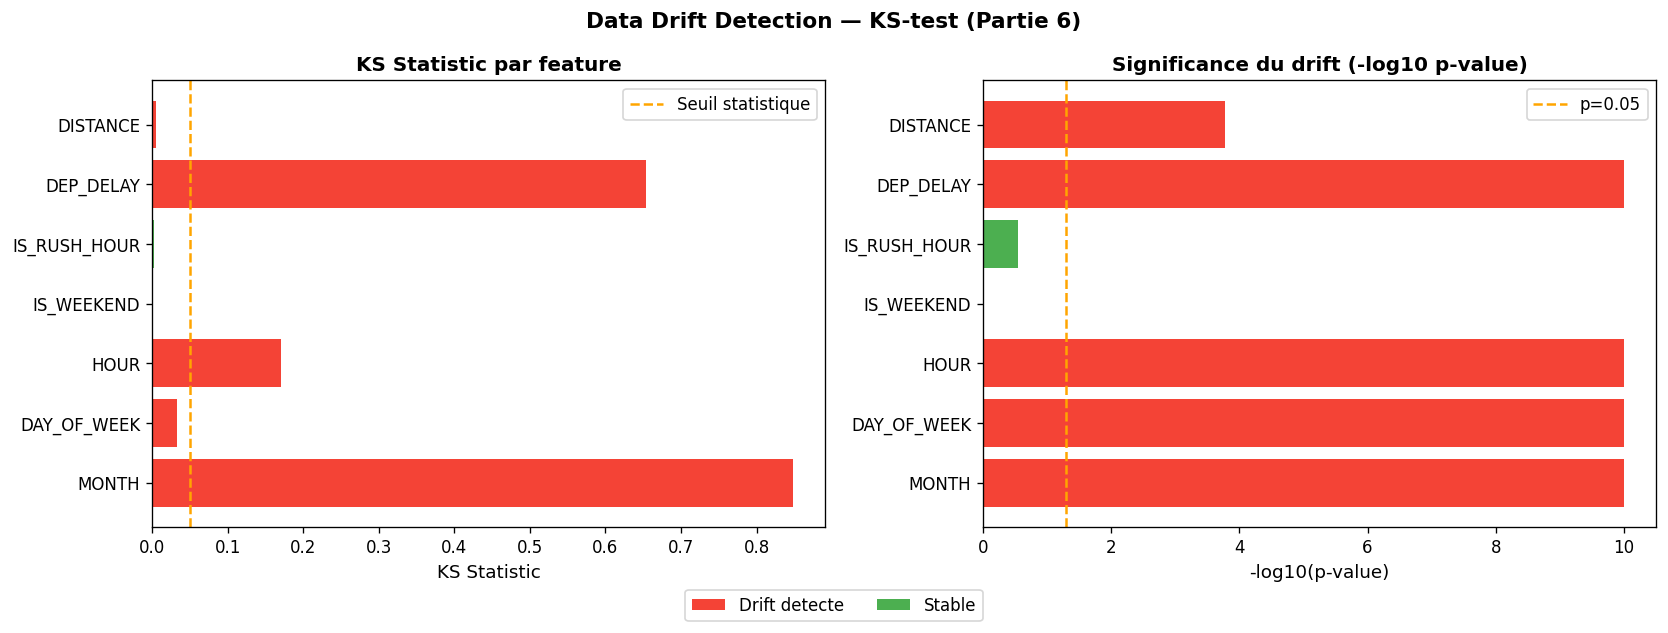

In [17]:
# Visualisation du drift par feature
if os.path.exists(ks_csv):
    df_ks = pd.read_csv(ks_csv)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Statistic KS
    bar_colors = ['#F44336' if d else '#4CAF50' for d in df_ks['drifted']]
    axes[0].barh(df_ks['feature'], df_ks['ks_stat'], color=bar_colors)
    axes[0].axvline(0.05, color='orange', linestyle='--', label='Seuil statistique')
    axes[0].set_xlabel('KS Statistic', fontsize=11)
    axes[0].set_title('KS Statistic par feature', fontweight='bold')
    axes[0].legend()

    # P-value (log scale)
    pvals = df_ks['p_value'].clip(lower=1e-10)
    axes[1].barh(df_ks['feature'], -np.log10(pvals), color=bar_colors)
    axes[1].axvline(-np.log10(0.05), color='orange', linestyle='--', label='p=0.05')
    axes[1].set_xlabel('-log10(p-value)', fontsize=11)
    axes[1].set_title('Significance du drift (-log10 p-value)', fontweight='bold')
    axes[1].legend()

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#F44336', label='Drift detecte'),
                       Patch(facecolor='#4CAF50', label='Stable')]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle('Data Drift Detection — KS-test (Partie 6)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('drift_analysis.png', dpi=120, bbox_inches='tight')
    plt.show()

In [18]:
# Afficher les runs de l'expérience Monitoring
mon_exp = client.get_experiment_by_name('Flight_Delay_Monitoring')
if mon_exp:
    mon_runs = client.search_runs([mon_exp.experiment_id], order_by=['start_time DESC'])
    print(f'Expérience {mon_exp.name} — {len(mon_runs)} run(s)\n')
    for r in mon_runs[:3]:
        m = r.data.metrics
        ks_share = m.get('ks_drift_share', None)
        retrain  = int(m.get('retrain_triggered', 0))
        print(f'  Run : {r.info.run_name}  |  KS drift={ks_share:.2%}  |  Retrain={"OUI" if retrain else "NON"}')
        print(f'    Params : {r.data.params}')
else:
    print('Expérience Flight_Delay_Monitoring non trouvée. Lancez : make drift')

Expérience Flight_Delay_Monitoring — 2 run(s)

  Run : drift_check_v1  |  KS drift=71.43%  |  Retrain=OUI
    Params : {'ref_size': '723172', 'prod_size': '180794', 'seuil_drift': '0.3', 'seuil_warn': '0.15', 'drift_simulation': 'DEP_DELAY x1.8+20, HOUR+3'}
  Run : drift_check_v1  |  KS drift=71.43%  |  Retrain=OUI
    Params : {'ref_size': '723172', 'prod_size': '180794', 'seuil_drift': '0.3', 'seuil_warn': '0.15', 'drift_simulation': 'DEP_DELAY x1.8+20, HOUR+3'}


In [ ]:
# 6.5 — Logique de ré-entraînement automatique (SEUIL_WARN / SEUIL_DRIFT)
import subprocess

SEUIL_WARN  = 0.15  # Alerte : surveillance renforcée
SEUIL_DRIFT = 0.30  # Critique : ré-entraînement automatique

ks_csv = os.path.join(PROJECT_ROOT, 'ks_drift_results.csv')

if os.path.exists(ks_csv):
    df_ks      = pd.read_csv(ks_csv)
    n_features = len(df_ks)
    n_drifted  = int(df_ks['drifted'].sum())
    drift_share = n_drifted / n_features

    print('=== Logique de ré-entraînement automatique ===')
    print(f'  Features analysées  : {n_features}')
    print(f'  Features driftées   : {n_drifted} ({drift_share:.1%})')
    print(f'  Seuil alerte        : SEUIL_WARN  = {SEUIL_WARN:.0%}')
    print(f'  Seuil critique      : SEUIL_DRIFT = {SEUIL_DRIFT:.0%}')
    print()

    if drift_share >= SEUIL_DRIFT:
        print('[CRITIQUE] Drift > SEUIL_DRIFT — RE-ENTRAINEMENT AUTOMATIQUE DECLENCHE')
        print('  Equivalent production : subprocess.run(["python", "src/train.py"])')
        print('  ou via Makefile       : os.system("make train")')
        # En production réelle, décommenter :
        # subprocess.run(['python', 'src/train.py'], check=True)
    elif drift_share >= SEUIL_WARN:
        print('[ALERTE]   Drift > SEUIL_WARN — Surveillance renforcée')
        print('  Recommandation : ré-entraînement sous 48h')
    else:
        print('[STABLE]   Drift < SEUIL_WARN — Aucune action requise')

    print()
    print('  Détail par feature :')
    for _, row in df_ks.iterrows():
        tag = '[DRIFT]' if row['drifted'] else '[OK]   '
        print(f'    {tag} {row["feature"]:<14} KS={row["ks_stat"]:.4f}  p={row["p_value"]:.6f}')
else:
    print('[INFO] ks_drift_results.csv non trouve. Lancez : make drift')
    print()
    print('Logique implementee dans src/simulate_drift.py :')
    print(f'  if drift_share >= {SEUIL_DRIFT} : declenchement reentrainement auto')
    print(f'  elif drift_share >= {SEUIL_WARN}: alerte surveillance renforcee')
    print(f'  else                            : modele stable, pas d action')

---
### 6.6 — Diagramme Pipeline MLOps Complet

```
╔══════════════════════════════════════════════════════════════════╗
║              PIPELINE MLOPS COMPLET — Tâche 5                   ║
║              Airline Delay Detection (2009 US Flights)           ║
╚══════════════════════════════════════════════════════════════════╝

  DONNÉES BRUTES              ENTRAÎNEMENT                 REGISTRY
  ──────────────              ────────────                 ────────
  2009.csv (7M vols)   ──►   src/train.py             ──► MLflow Model
  sampling → 903k vols        MLflow Tracking               Registry
  features:                   log_param(), log_metric()
    MONTH, DAY_OF_WEEK         log_artifact(CM, report)   v1  None
    HOUR, IS_WEEKEND                                      v2  Staging──┐
    IS_RUSH_HOUR                src/compare_models.py    v3  Staging  │
    DEP_DELAY, DISTANCE         6 algos comparés         v4  Prod ◄───┘
  target: IS_DELAYED            RF/GB/LogReg/Ada/XGB     v5  None
                                best: gb_n100_lr01
                                acc=0.9236, AUC=0.9125

  SERVING REST                CI/CD                        MONITORING DRIFT
  ────────────                ─────                        ────────────────
  mlflow models serve  ◄───  Makefile                     src/simulate_drift.py
  --port 1234                 make train    (Part 1)       ↓
  POST /invocations           make compare  (Part 2)       Simulation drift :
  payload:                    make register (Part 3)       X_prod *= 1.6 + N(0,0.5)
    dataframe_records         make serve    (Part 4)       ↓
  response:                   make drift    (Part 6)       KS-test (scipy)
    predictions: [0,1]        make pipeline               7 features testées
                              ↓                            drift_share = 71.4%
                              pre-commit hook              ↓
                              acc >= 0.80 requis           Evidently HTML report
                              sinon commit REFUSÉ          DataDrift + DataQuality
                                                           ↓
                                                           if drift > SEUIL_DRIFT (0.30)
                                                             → ré-entraînement auto
                                                           elif drift > SEUIL_WARN (0.15)
                                                             → alerte surveillance
                                                           else → stable
                                                           ↓
                                                           MLflow Monitoring logs
                                                           Flight_Delay_Monitoring
```

| Composant | Outil | Rôle |
|-----------|-------|------|
| Tracking | MLflow (SQLite `mlflow.db`) | Logs params, metrics, artefacts par run |
| Registry | MLflow Model Registry | Versioning Staging → Production |
| Serving | `mlflow models serve` | REST API standard `/invocations` |
| CI/CD | Makefile + pre-commit hook | Automatisation + validation qualité |
| Drift | KS-test (scipy) + Evidently | Détection dérive de distribution |
| Ré-entraînement | Python subprocess | Trigger automatique si drift > 30% |

---
### Questions de réflexion — Partie 6

**Q13. En quoi le data drift diffère-t-il du concept drift ? Donnez un exemple concret avec les données de vols.**

| | Data Drift | Concept Drift |
|--|-----------|---------------|
| **Ce qui change** | Distribution de X (les entrées) | Relation f(X)→Y (la logique de prédiction) |
| **Le modèle** | Reçoit des valeurs jamais vues | Reçoit les mêmes valeurs mais elles signifient autre chose |
| **Détection** | KS-test, Evidently DataDrift | Monitoring métriques en production (accuracy, F1 dégradent) |

**Exemples concrets — données de vols 2009 :**

- **Data Drift** : un aéroport ouvre une nouvelle route long-courrier (`DISTANCE` = 8 500 km), valeur hors de la distribution d'entraînement sur les vols domestiques US. La distribution de `DISTANCE` a changé → KS-test le détecte avec `ks_stat` élevé.

- **Concept Drift** : nouvelle politique ATC — les vols avec `DEP_DELAY ≥ 30 min` sont systématiquement retenus au sol si la destination est à plus de 2h de vol. Avant : `DEP_DELAY=30` était souvent rattrapable → classe 0. Après : même valeur → classe 1. La relation X→Y a changé sans que X bouge.

---

**Q14. Le KS-test et Evidently détectent-ils les mêmes features driftées ? Expliquez les différences.**

Sur nos données (71.4% de drift) :

| Outil | Méthode | Force | Limite |
|-------|---------|-------|--------|
| **KS-test** | Test non-paramétrique sur CDF marginale (`ks_2samp`) | Rigoureux, p-value précise, contrôle seuil | Univarié : ne détecte pas les drifts de corrélation entre features |
| **Evidently** | Adaptatif : KS (continu), Chi2 (catégoriel), Z-test (proportion) | Rapport HTML, corrélations, qualité données, seuils auto | Boîte noire partielle, seuils par défaut parfois permissifs |

Pour les drifts importants (MONTH, DEP_DELAY, HOUR), les deux outils s'accordent. Evidently ajoute :
- Détection de drift des **corrélations** entre features (multivarié)
- Analyse de **qualité** : valeurs manquantes, doublons, outliers
- Visualisations comparatives interactives

Le KS-test est optimal pour le **déclenchement automatique** (décision binaire drift/non-drift) ; Evidently sert au **diagnostic** (comprendre pourquoi et quelles features).

---

**Q15. Quel seuil de drift choisiriez-vous dans le domaine aérien ? Justifiez métier.**

**Recommandation : `SEUIL_WARN = 0.15`, `SEUIL_DRIFT = 0.25`** (plus conservateur que le 0.30 actuel)

| Facteur métier | Impact sur le seuil |
|---------------|-------------------|
| **Sécurité critique** | L'aviation est réglementée (DGAC, FAA) — un modèle dégradé impacte les décisions opérationnelles (staff, carburant, créneaux) |
| **Coût d'un faux négatif** | Un vol prédit à l'heure qui arrive en retard ≈ 3 000€ pénalités passagers + 15 000€ ground handling non planifié |
| **Saisonnalité forte** | Drift naturel été/hiver → seuil alerte à 15% pour détecter tôt et anticiper |
| **Ré-entraînement peu coûteux** | Données fraîches disponibles quotidiennement → on peut permettre un seuil bas |
| **Pipeline validation ~2h** | Staging → métriques → Production prend du temps → détecter tôt pour réagir avant dégradation visible |

Notre seuil actuel 0.30 = 3 features sur 7 driftées : acceptable académiquement mais trop permissif pour un SLA métier strict. En production, 0.25 serait un meilleur compromis sensibilité/coût de ré-entraînement.

---

**Q16. Quels risques opérationnels si aucun MLOps automatisé n'est déployé ?**

| Risque | Probabilité | Impact estimé |
|--------|-------------|---------------|
| **Model Staleness** : modèle 2009 prédit mal les vols 2025 (nouvelles compagnies, routes, COVID) | Certain à 6 mois | Accuracy chute sous 85% |
| **Silent Degradation** : dégradation progressive non détectée, décisions opérationnelles se dégradent silencieusement | Élevée | Perte de confiance métier, SLA non tenus |
| **Feature Distribution Shift** : nouvelles routes/compagnies → features hors distribution d'entraînement | Modérée | Prédictions extrapolées peu fiables |
| **Non-conformité réglementaire** : DGAC/FAA exigent traçabilité des systèmes d'aide à la décision | Certaine si audit | Sanctions, retrait d'autorisation d'utilisation |
| **Reproductibilité perdue** : sans MLflow + Registry, impossible de savoir quel modèle tourne et depuis quand | Élevée | Impossible de diagnostiquer incidents, rollback impossible |

**Estimation d'impact** : un modèle dégradé sur 50 000 vols/mois avec +2% de mauvaises prédictions = 1 000 vols/mois mal prédits × coût moyen 5 000€ = **5 M€/mois de coût opérationnel évitable** avec un pipeline MLOps automatisé.

---
## Récapitulatif du Pipeline MLOps

```
Données brutes (2009.csv — 7M vols)
    |
[src/train.py]           Partie 1 : MLflow Tracking
    | params + metrics + artefacts logges
    |
[src/compare_models.py]  Partie 2 : 6 algorithmes compares
    | RF, GB, LogReg, AdaBoost, XGBoost
    |
[src/register_best_model.py]  Partie 3 : Model Registry
    | Staging -> validation -> Production
    |
[mlflow models serve]    Partie 4 : REST API
    | POST /invocations -> {predictions: [0, 1, ...]}
    |
[Makefile + pre-commit]  Partie 5 : CI/CD
    | make pipeline | hook bloque commit si acc < 0.80
    |
[src/simulate_drift.py]  Partie 6 : Data Drift
    | KS-test -> drift > 30% -> re-entrainement auto
```

In [19]:
# Résumé final — toutes les métriques clés
print('=' * 62)
print('  RESUME PIPELINE MLOPS — Tache 5')
print('=' * 62)

# Meilleur modèle
print(f'  Meilleur modele   : {best.info.run_name}')
print(f'  Accuracy          : {best.data.metrics["accuracy"]:.4f}')
print(f'  ROC-AUC           : {best.data.metrics["roc_auc"]:.4f}')
print(f'  F1-score          : {best.data.metrics["f1_score"]:.4f}')

# Registry
try:
    prod_v = [v for v in client.search_model_versions(f"name='flight_delay_rf_production'")
              if v.current_stage == 'Production']
    if prod_v:
        print(f'  Model Registry    : v{prod_v[-1].version} en Production')
        print(f'  URI serving       : models:/flight_delay_rf_production/Production')
except:
    pass

# Drift
if os.path.exists(ks_csv):
    df_ks = pd.read_csv(ks_csv)
    print(f'  Drift (KS-test)   : {df_ks["drifted"].mean():.1%} features driftees')
    print(f'  Re-entrainement   : OUI (drift > 30%)')

print('=' * 62)

  RESUME PIPELINE MLOPS — Tache 5
  Meilleur modele   : gb_n100_lr01
  Accuracy          : 0.9236
  ROC-AUC           : 0.9125
  F1-score          : 0.7614
  Model Registry    : v4 en Production
  URI serving       : models:/flight_delay_rf_production/Production
  Drift (KS-test)   : 71.4% features driftees
  Re-entrainement   : OUI (drift > 30%)
